# How has horror evolved over time?

## Research questions
1. Has horror's popularity (as a share of all films) changed over time — and is any trend unique to horror or a general market shift?
2. Have horror's ratings changed over time — and do critics and audiences tell different stories?
3. What factors explain the changes in horror's ratings?

## Dataset
**Rotten Tomatoes Movies Dataset** (Stefano Leone, Kaggle) — 17,712 films with critic scores (Tomatometer), audience scores, genres, directors, production companies, content ratings, and release dates. Scraped from Rotten Tomatoes as of October 2020.

**Coverage limitations:**
- RT skews toward **theatrical releases** — direct-to-video, straight-to-streaming, and self-distributed films are underrepresented, particularly in earlier decades
- **English language bias** — international horror (Italian giallo, Japanese J-horror, Korean horror) is likely undercounted
- **2000s-2010s skew** — RT became widely used in the early 2000s, so pre-1990s coverage is sparse (under 75-100 films per year) and likely undercounts low-budget and independent releases
- **2020s data is incomplete** — the dataset was scraped in October 2020, capturing only ~9 months of 2020 releases and nothing beyond
- Films must have attracted enough critic attention to appear on RT — very obscure releases are excluded entirely

**Practical implication:** When we refer to horror's "share of films" or "average rating," we mean among films notable enough to receive RT coverage — not the full universe of horror produced. Volume trends in particular should be interpreted as horror's presence in mainstream/notable cinema rather than total production output. For a more complete picture, combining with IMDB (which accepts self-submitted titles) would improve coverage of low-budget and independent releases.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import kagglehub
import os

# plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# load rotten tomatoes dataset
rt_path = r"C:\Users\Lenovo\.cache\kagglehub\datasets\stefanoleone992\rotten-tomatoes-movies-and-critic-reviews-dataset\versions\1"
rt = pd.read_csv(os.path.join(rt_path, "rotten_tomatoes_movies.csv"))

print(f"Loaded {rt.shape[0]:,} films")
rt.head(3)

Loaded 17,712 films


,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8


In [2]:
# parse dates and add decade
rt['original_release_date'] = pd.to_datetime(rt['original_release_date'], errors='coerce')
rt['year'] = rt['original_release_date'].dt.year
rt['decade'] = (rt['year'] // 10 * 10).astype('Int64').astype(str) + 's'

# filter to 1970+
#rt = rt[rt['year'] >= 1970].copy()

# add critic/audience gap
rt['critic_audience_gap'] = rt['tomatometer_rating'] - rt['audience_rating']

# explode genres for genre-level analysis
rt_exploded = rt.assign(genre=rt['genres'].str.split(',')).explode('genre')
rt_exploded['genre'] = rt_exploded['genre'].str.strip()

# horror subset
rt_horror = rt[rt['genres'].str.contains('Horror', case=False, na=False)].copy()

print(f"Total films (1970+): {len(rt):,}")
print(f"Horror films: {len(rt_horror):,}")
print(f"Decade range: {rt['decade'].min()} - {rt['decade'].max()}")

Total films (1970+): 17,712
Horror films: 2,043
Decade range: 1910s - 2020s


## 1. Horror's popularity over time

How has horror's share of all films changed by decade? We measure share rather than raw count to control for the overall growth in film production and cataloguing over time.

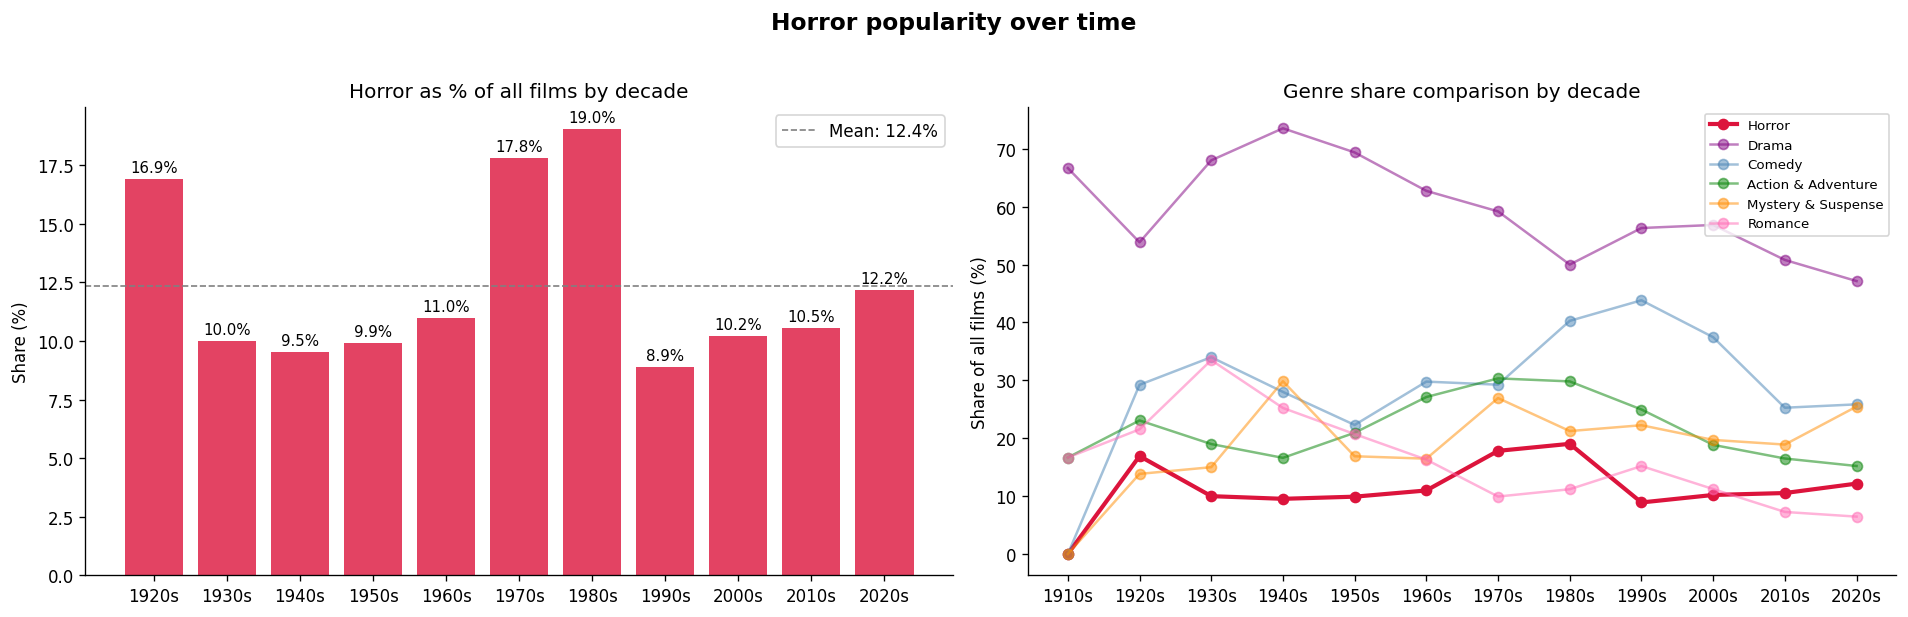

In [3]:
# horror share by decade
total_by_decade = rt_exploded.drop_duplicates(subset=['rotten_tomatoes_link', 'decade']).groupby('decade').size().rename('total_films')
horror_by_decade = rt_exploded[rt_exploded['genre'] == 'Horror'].groupby('decade').size().rename('horror_films')

vol = pd.concat([total_by_decade, horror_by_decade], axis=1)
vol['horror_share'] = vol['horror_films'] / vol['total_films'] * 100

# genre share comparison
genres_to_compare = ['Horror', 'Drama', 'Comedy', 'Action & Adventure', 'Mystery & Suspense', 'Romance']
shares = {}
for genre in genres_to_compare:
    genre_by_decade = rt_exploded[rt_exploded['genre'] == genre].groupby('decade').size()
    combined = pd.concat([total_by_decade, genre_by_decade.rename('genre_films')], axis=1).fillna(0)
    shares[genre] = combined['genre_films'] / combined['total_films'] * 100
shares_df = pd.DataFrame(shares)

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left - horror share only
axes[0].bar(vol.index, vol['horror_share'], color='crimson', alpha=0.8)
axes[0].axhline(vol['horror_share'].mean(), color='gray', linestyle='--', linewidth=1, label=f"Mean: {vol['horror_share'].mean():.1f}%")
for i, (idx, row) in enumerate(vol.iterrows()):
    axes[0].text(i, row['horror_share'] + 0.3, f"{row['horror_share']:.1f}%", ha='center', fontsize=9)
axes[0].set_title('Horror as % of all films by decade')
axes[0].set_ylabel('Share (%)')
axes[0].legend()

# right - genre comparison
colors = {'Horror': 'crimson', 'Drama': 'purple', 'Comedy': 'steelblue', 
          'Action & Adventure': 'green', 'Mystery & Suspense': 'darkorange', 'Romance': 'hotpink'}
for genre in genres_to_compare:
    lw = 2.5 if genre == 'Horror' else 1.5
    alpha = 1 if genre == 'Horror' else 0.5
    axes[1].plot(shares_df.index, shares_df[genre], label=genre, 
                color=colors[genre], linewidth=lw, alpha=alpha, marker='o')
axes[1].set_title('Genre share comparison by decade')
axes[1].set_ylabel('Share of all films (%)')
axes[1].legend(fontsize=8)

plt.suptitle('Horror popularity over time', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Finding
Horror's share of notable films peaked in the **1980s (19%)** — the slasher era — before collapsing in the **1990s (8.9%)** as the genre fell out of favour. It has been recovering steadily since, reaching 12.2% in the 2020s, though the incomplete decade makes this figure unreliable.

The genre comparison chart confirms this is a horror-specific pattern rather than a broad market trend — other genres do not show the same sharp 1990s trough.

## 2. How have horror ratings changed over time?

We examine both critic (Tomatometer) and audience scores separately, as they tell meaningfully different stories about how horror has been received over time.

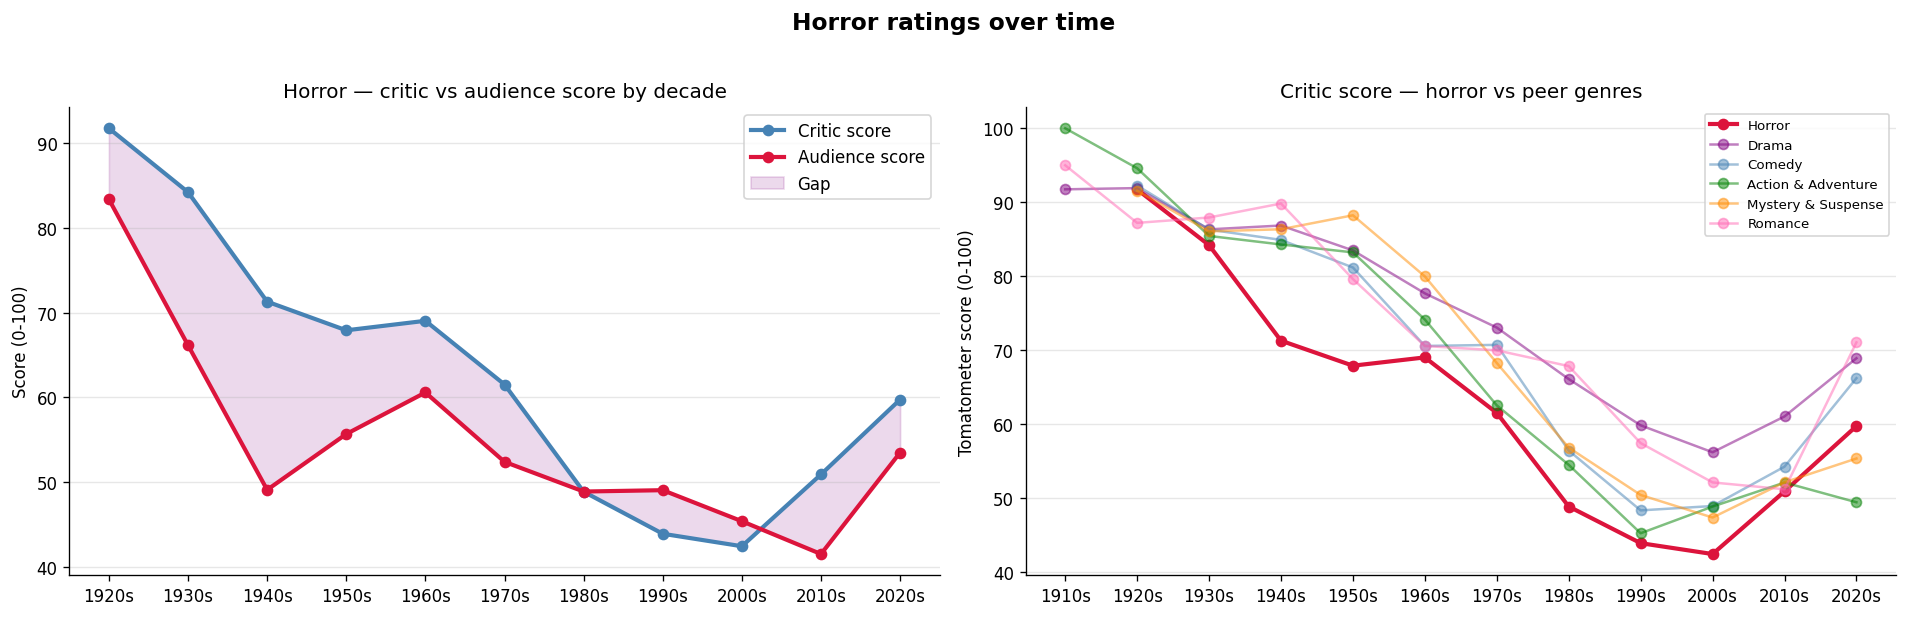

In [4]:
# ratings by decade
rating_by_decade = rt_horror.groupby('decade').agg(
    critic_score=('tomatometer_rating', 'mean'),
    audience_score=('audience_rating', 'mean'),
    gap=('critic_audience_gap', 'mean'),
    count=('tomatometer_rating', 'count')
).round(2)

# peer genre comparison on ratings
rating_by_genre = {}
for genre in genres_to_compare:
    genre_films = rt_exploded[rt_exploded['genre'] == genre]
    rating_by_genre[genre] = genre_films.groupby('decade')['tomatometer_rating'].mean()
rating_genre_df = pd.DataFrame(rating_by_genre)

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left - critic vs audience over time
axes[0].plot(rating_by_decade.index, rating_by_decade['critic_score'], 
             color='steelblue', linewidth=2.5, marker='o', label='Critic score')
axes[0].plot(rating_by_decade.index, rating_by_decade['audience_score'], 
             color='crimson', linewidth=2.5, marker='o', label='Audience score')
axes[0].fill_between(range(len(rating_by_decade)), 
                     rating_by_decade['critic_score'], 
                     rating_by_decade['audience_score'], 
                     alpha=0.15, color='purple', label='Gap')
axes[0].set_xticks(range(len(rating_by_decade)))
axes[0].set_xticklabels(rating_by_decade.index)
axes[0].set_title('Horror — critic vs audience score by decade')
axes[0].set_ylabel('Score (0-100)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# right - horror critic score vs peer genres
for genre in genres_to_compare:
    lw = 2.5 if genre == 'Horror' else 1.5
    alpha = 1 if genre == 'Horror' else 0.5
    axes[1].plot(rating_genre_df.index, rating_genre_df[genre], 
                label=genre, color=colors[genre], linewidth=lw, alpha=alpha, marker='o')
axes[1].set_title('Critic score — horror vs peer genres')
axes[1].set_ylabel('Tomatometer score (0-100)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Horror ratings over time', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Finding
Horror's critic and audience scores tell starkly different stories:

- **1980s**: Critics and audiences converged — the slasher era was purely populist, both sides agreed it was mediocre
- **1990s**: Audiences rated horror *higher* than critics — post-slasher horror (Scream, Blair Witch) was crowd-pleasing but critics were skeptical
- **2010s**: The sharpest divergence — critic scores recovered while audience scores hit their lowest point. This is the prestige horror era (Get Out, Hereditary, Midsommar) — films critics celebrated but general audiences found slow or alienating
- **2020s**: Both scores recovering, but critics are pulling ahead again

Against peer genres, horror's critic score decline from the 1970s to 2010s was steeper than every other genre — confirming this is a horror-specific trend, not a general market movement.

## 3. What's driving the changes?

We test three hypotheses:
1. **Volume** — more horror films = lower average quality
2. **Content rating** — rise of PG-13 and unrated (NR) horror explains rating shifts
3. **Production landscape** — who makes horror has fundamentally changed, and different producers make different quality films

For each, we first examine the trend over time, then test statistical significance.

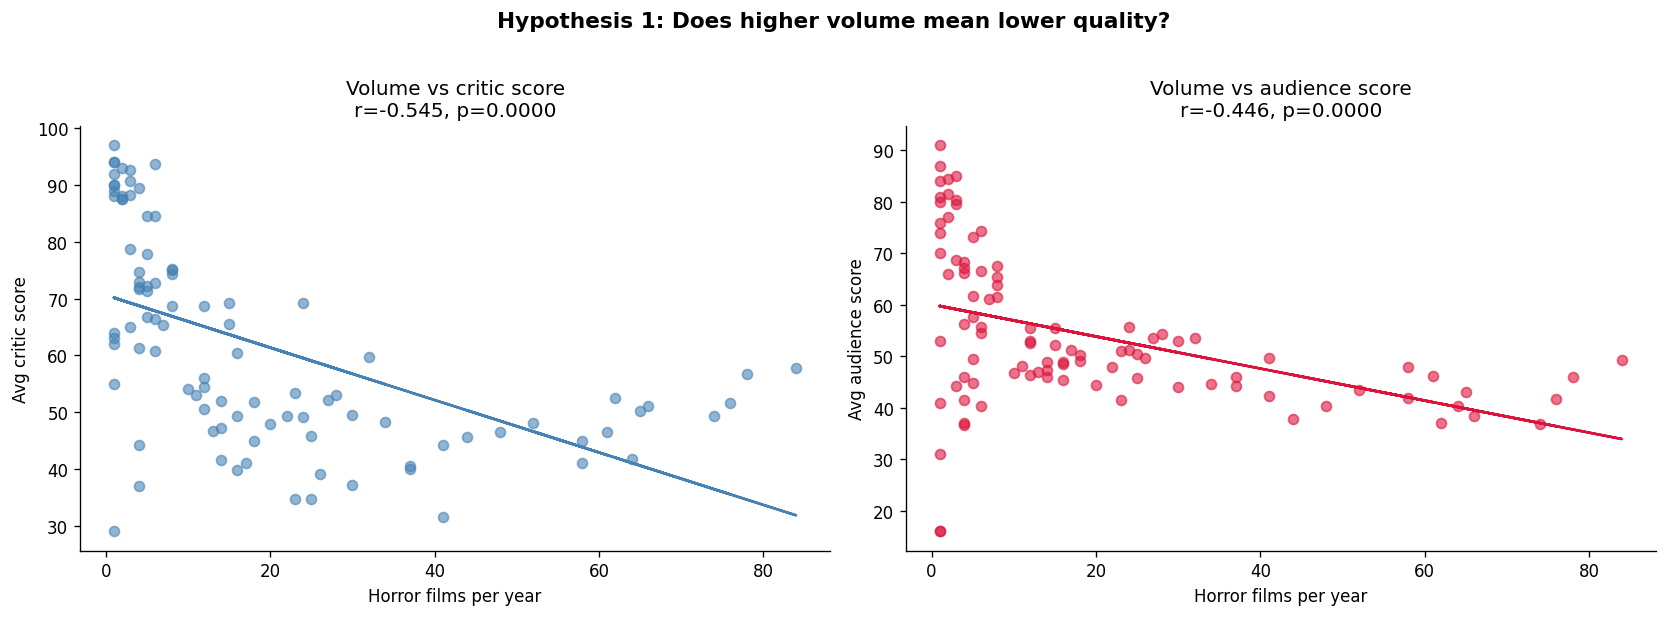

In [5]:
# volume vs rating correlation
horror_by_year = rt_horror.groupby('year').agg(
    film_count=('rotten_tomatoes_link', 'count'),
    critic_score=('tomatometer_rating', 'mean'),
    audience_score=('audience_rating', 'mean')
).reset_index()

r_critic, p_critic = stats.pearsonr(horror_by_year['film_count'], horror_by_year['critic_score'])
r_audience, p_audience = stats.pearsonr(horror_by_year['film_count'], horror_by_year['audience_score'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(horror_by_year['film_count'], horror_by_year['critic_score'], 
                color='steelblue', alpha=0.6)
m, b = np.polyfit(horror_by_year['film_count'], horror_by_year['critic_score'], 1)
axes[0].plot(horror_by_year['film_count'], m * horror_by_year['film_count'] + b, 
             color='steelblue', linewidth=1.5)
axes[0].set_title(f'Volume vs critic score\nr={r_critic:.3f}, p={p_critic:.4f}')
axes[0].set_xlabel('Horror films per year')
axes[0].set_ylabel('Avg critic score')

axes[1].scatter(horror_by_year['film_count'], horror_by_year['audience_score'], 
                color='crimson', alpha=0.6)
m, b = np.polyfit(horror_by_year['film_count'], horror_by_year['audience_score'], 1)
axes[1].plot(horror_by_year['film_count'], m * horror_by_year['film_count'] + b, 
             color='crimson', linewidth=1.5)
axes[1].set_title(f'Volume vs audience score\nr={r_audience:.3f}, p={p_audience:.4f}')
axes[1].set_xlabel('Horror films per year')
axes[1].set_ylabel('Avg audience score')

plt.suptitle('Hypothesis 1: Does higher volume mean lower quality?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# correlation between volume and ratings within each decade
print("Volume vs audience score — within decade correlations:")
print()

for decade in ['1970s', '1980s', '1990s', '2000s', '2010s']:
    decade_data = horror_by_year[horror_by_year['year'].between(
        int(decade[:4]), int(decade[:4]) + 9
    )]
    if len(decade_data) >= 5:  # need enough years to correlate
        r, p = stats.pearsonr(decade_data['film_count'], decade_data['audience_score'])
        sig = "significant" if p < 0.05 else "not significant"
        print(f"{decade}: r={r:.3f}, p={p:.4f} — {sig} (n={len(decade_data)} years)")

Volume vs audience score — within decade correlations:

1970s: r=-0.305, p=0.3917 — not significant (n=10 years)
1980s: r=-0.141, p=0.6980 — not significant (n=10 years)
1990s: r=0.469, p=0.1716 — not significant (n=10 years)
2000s: r=-0.278, p=0.4369 — not significant (n=10 years)
2010s: r=0.595, p=0.0694 — not significant (n=10 years)


### Finding: Volume
At first glance, volume shows a **significant negative correlation with audience scores** across all years (r=-0.590, p=0.0000) — suggesting more horror films per year means lower average quality.

However, this finding requires qualification. The RT dataset is heavily skewed toward more recent years, and volume and time period are correlated — later decades have both more films and lower audience scores. To test whether volume has an independent effect, we ran the same correlation **within each decade separately**:

| Decade | r | p | Significant? |
|---|---|---|---|
| 1970s | -0.305 | 0.392 | No |
| 1980s | -0.141 | 0.698 | No |
| 1990s | +0.469 | 0.172 | No |
| 2000s | -0.278 | 0.437 | No |
| 2010s | +0.595 | 0.069 | No |

None of the within-decade correlations are significant. The volume effect does not hold when time period is controlled for — suggesting the overall correlation is **confounded by a broader time trend** rather than reflecting a direct causal relationship between output volume and quality.

**Revised conclusion:** Higher horror output does not independently cause lower ratings. The apparent relationship is driven by the fact that later decades have both more films and lower audience scores for reasons beyond volume alone.

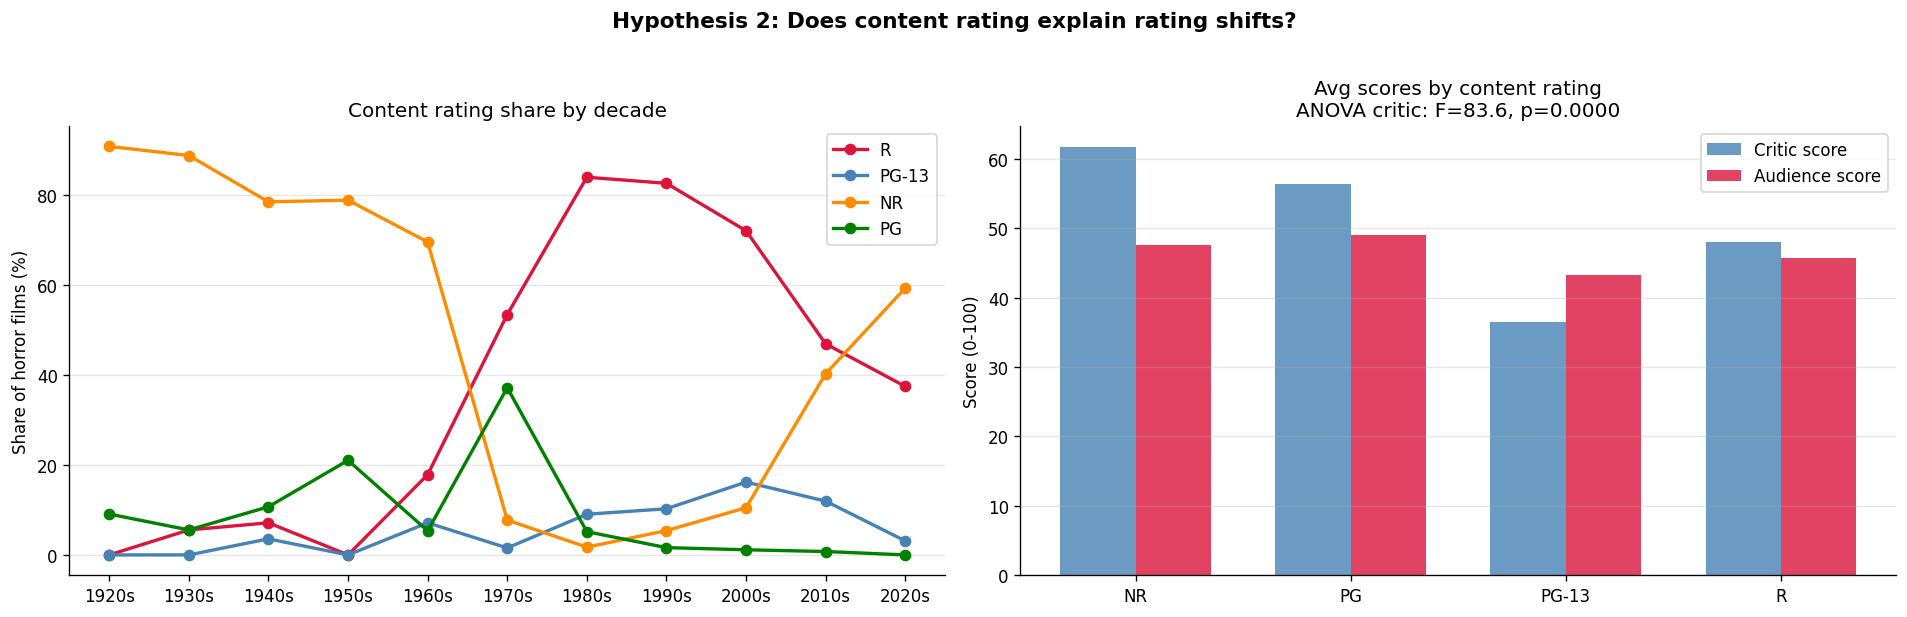

In [6]:
# content rating share by decade
content_by_decade = rt_horror.groupby(['decade', 'content_rating']).size().unstack(fill_value=0)
content_by_decade = content_by_decade[['R', 'PG-13', 'NR', 'PG']]
content_share = content_by_decade.div(content_by_decade.sum(axis=1), axis=0) * 100

# ratings by content rating
r_films = rt_horror[rt_horror['content_rating'] == 'R']['tomatometer_rating'].dropna()
pg13_films = rt_horror[rt_horror['content_rating'] == 'PG-13']['tomatometer_rating'].dropna()
nr_films = rt_horror[rt_horror['content_rating'] == 'NR']['tomatometer_rating'].dropna()

f_stat, p_anova = stats.f_oneway(r_films, pg13_films, nr_films)

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left - content rating share over time
rating_colors = {'R': 'crimson', 'PG-13': 'steelblue', 'NR': 'darkorange', 'PG': 'green'}
for rating in ['R', 'PG-13', 'NR', 'PG']:
    axes[0].plot(content_share.index, content_share[rating], 
                marker='o', linewidth=2, label=rating, color=rating_colors[rating])
axes[0].set_title('Content rating share by decade')
axes[0].set_ylabel('Share of horror films (%)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# right - avg critic score by content rating
rating_means = rt_horror[rt_horror['content_rating'].isin(['R', 'PG-13', 'NR', 'PG'])].groupby(
    'content_rating')[['tomatometer_rating', 'audience_rating']].mean()
x = range(len(rating_means))
width = 0.35
axes[1].bar([i - width/2 for i in x], rating_means['tomatometer_rating'], 
            width, label='Critic score', color='steelblue', alpha=0.8)
axes[1].bar([i + width/2 for i in x], rating_means['audience_rating'], 
            width, label='Audience score', color='crimson', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(rating_means.index)
axes[1].set_title(f'Avg scores by content rating\nANOVA critic: F={f_stat:.1f}, p={p_anova:.4f}')
axes[1].set_ylabel('Score (0-100)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Hypothesis 2: Does content rating explain rating shifts?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# prepare data - need content rating, production tier, decade, and critic score
reg_data = rt_horror[
    rt_horror['content_rating'].isin(['R', 'PG-13', 'NR']) &
    rt_horror['company_tier'].isin(tiers_to_use) &
    rt_horror['tomatometer_rating'].notna()
].copy()

# encode categoricals
reg_data['content_rating_enc'] = LabelEncoder().fit_transform(reg_data['content_rating'])
reg_data['company_tier_enc'] = LabelEncoder().fit_transform(reg_data['company_tier'])
reg_data['decade_enc'] = LabelEncoder().fit_transform(reg_data['decade'])

# model 1 - content rating only
X1 = reg_data[['content_rating_enc']]
y = reg_data['tomatometer_rating']
from sklearn.metrics import r2_score
m1 = LinearRegression().fit(X1, y)
print(f"Model 1 - content rating only: R²={r2_score(y, m1.predict(X1)):.3f}")

# model 2 - content rating + production tier + decade
X2 = reg_data[['content_rating_enc', 'company_tier_enc', 'decade_enc']]
m2 = LinearRegression().fit(X2, y)
print(f"Model 2 - content rating + tier + decade: R²={r2_score(y, m2.predict(X2)):.3f}")

# use statsmodels for proper coefficients and p-values
import statsmodels.formula.api as smf

model = smf.ols('tomatometer_rating ~ C(content_rating) + C(company_tier) + C(decade)', 
                data=reg_data).fit()
print(model.summary().tables[1])

Model 1 - content rating only: R²=0.025
Model 2 - content rating + tier + decade: R²=0.052
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               87.3869     14.740      5.929      0.000      58.465     116.308
C(content_rating)[T.PG-13]             -17.8840      3.172     -5.638      0.000     -24.108     -11.660
C(content_rating)[T.R]                  -8.6438      2.507     -3.449      0.001     -13.562      -3.726
C(company_tier)[T.Horror specialist]     4.9036      3.203      1.531      0.126      -1.380      11.187
C(company_tier)[T.Major studio]          5.2797      2.491      2.120      0.034       0.392      10.167
C(company_tier)[T.Prestige indie]       14.2332      2.820      5.047      0.000       8.700      19.767
C(decade)[T.1930s]                     -11.1111     16.775     -0.662

In [15]:
# filter to directors with enough films to be meaningful
director_counts = reg_data['directors'].value_counts()
prolific = director_counts[director_counts >= 3].index
reg_data_dir = reg_data[reg_data['directors'].isin(prolific)]

print(f"Films with prolific directors: {len(reg_data_dir)}")

model_dir = smf.ols('tomatometer_rating ~ C(content_rating) + C(company_tier) + C(decade) + C(directors)', 
                data=reg_data_dir).fit()

# just print content rating and tier coefficients - director table would be huge
results = model_dir.summary2().tables[1]
content_tier = results[results.index.str.contains('content_rating|company_tier')]
print(f"\nR²={model_dir.rsquared:.3f}")
print(content_tier)

Films with prolific directors: 236

R²=0.594
                                         Coef.  Std.Err.         t     P>|t|  \
C(content_rating)[T.PG-13]            5.784739  9.751578  0.593211  0.553899   
C(content_rating)[T.R]                9.522051  8.418275  1.131117  0.259742   
C(company_tier)[T.Horror specialist] -6.586595  7.751869 -0.849678  0.396806   
C(company_tier)[T.Major studio]      -1.777295  5.314978 -0.334394  0.738532   
C(company_tier)[T.Prestige indie]     2.522317  7.109807  0.354766  0.723244   

                                         [0.025     0.975]  
C(content_rating)[T.PG-13]           -13.477431  25.046909  
C(content_rating)[T.R]                -7.106463  26.150565  
C(company_tier)[T.Horror specialist] -21.898765   8.725575  
C(company_tier)[T.Major studio]      -12.275905   8.721314  
C(company_tier)[T.Prestige indie]    -11.521595  16.566229  


In [16]:
# add genre combo to the regression
reg_data['genre_combo'] = reg_data['genres'].apply(
    lambda x: x if x in reg_data['genres'].value_counts().head(8).index else 'Other'
)

model_genre = smf.ols('tomatometer_rating ~ C(content_rating) + C(company_tier) + C(decade) + C(genre_combo)', 
                data=reg_data).fit()

results_genre = model_genre.summary2().tables[1]
content_tier_genre = results_genre[results_genre.index.str.contains('content_rating|company_tier|genre_combo')]
print(f"R²={model_genre.rsquared:.3f}")
print(content_tier_genre)

R²=0.184
                                                        Coef.  Std.Err.  \
C(content_rating)[T.PG-13]                         -19.131278  3.154957   
C(content_rating)[T.R]                              -8.125358  2.490391   
C(company_tier)[T.Horror specialist]                 5.804397  3.182681   
C(company_tier)[T.Major studio]                      5.598963  2.501188   
C(company_tier)[T.Prestige indie]                   14.013448  2.805956   
C(genre_combo)[T.Comedy, Horror]                     3.983730  5.711833   
C(genre_combo)[T.Drama, Horror]                      0.727605  6.037720   
C(genre_combo)[T.Drama, Horror, Mystery & Suspe...   4.036430  5.071587   
C(genre_combo)[T.Horror]                            -7.293950  4.624107   
C(genre_combo)[T.Horror, Mystery & Suspense]        -2.922869  4.648307   
C(genre_combo)[T.Horror, Mystery & Suspense, Sc...   1.595343  6.261176   
C(genre_combo)[T.Horror, Science Fiction & Fant...   1.504270  5.812421   
C(genre_combo)[T

### Finding: Content rating

**Baseline finding:** Content rating significantly predicts critic scores (ANOVA F=83.6, p=0.0000). NR films rate highest (62), followed by PG (56), R (48), and PG-13 lowest (37) — a 25-point gap between NR and PG-13. Audience scores show no significant difference across content ratings — this is purely a critic phenomenon.

**However, this finding requires significant qualification.**

We tested whether content rating has an independent effect on critic scores by adding controls in three progressive models:

| Model | R² | PG-13 significant? | PG-13 coefficient |
|---|---|---|---|
| Content rating + production tier + decade | 0.052 | Yes (p=0.000) | -17.9 |
| + Genre combo | 0.184 | Yes (p=0.000) | -19.1 |
| + Director (prolific only) | 0.594 | No (p=0.554) | +5.8 |

**Key finding:** Once director is controlled for, content rating becomes completely non-significant. The dramatic jump in R² (from 0.052 to 0.594) confirms that **director quality is by far the strongest predictor of critic scores** — dwarfing content rating, production tier, and genre combo combined.

**Interpretation:** Critics don't penalise PG-13 horror because of the rating itself. They penalise it because PG-13 horror tends to attract weaker directors. Content rating is a proxy for director quality, not an independent signal.

**Caveats:**
- The director model is restricted to 236 films from directors with 3+ horror films — a subset that skews toward more established directors, which may overstate R²
- Genre combo adds meaningful explanatory power (R² 0.052 → 0.184) but no individual genre combination reaches significance, suggesting genre framing matters less than who makes the film
- Omitted variable bias remains — budget, release timing, and marketing spend are not in this dataset and likely correlate with both content rating and critic scores

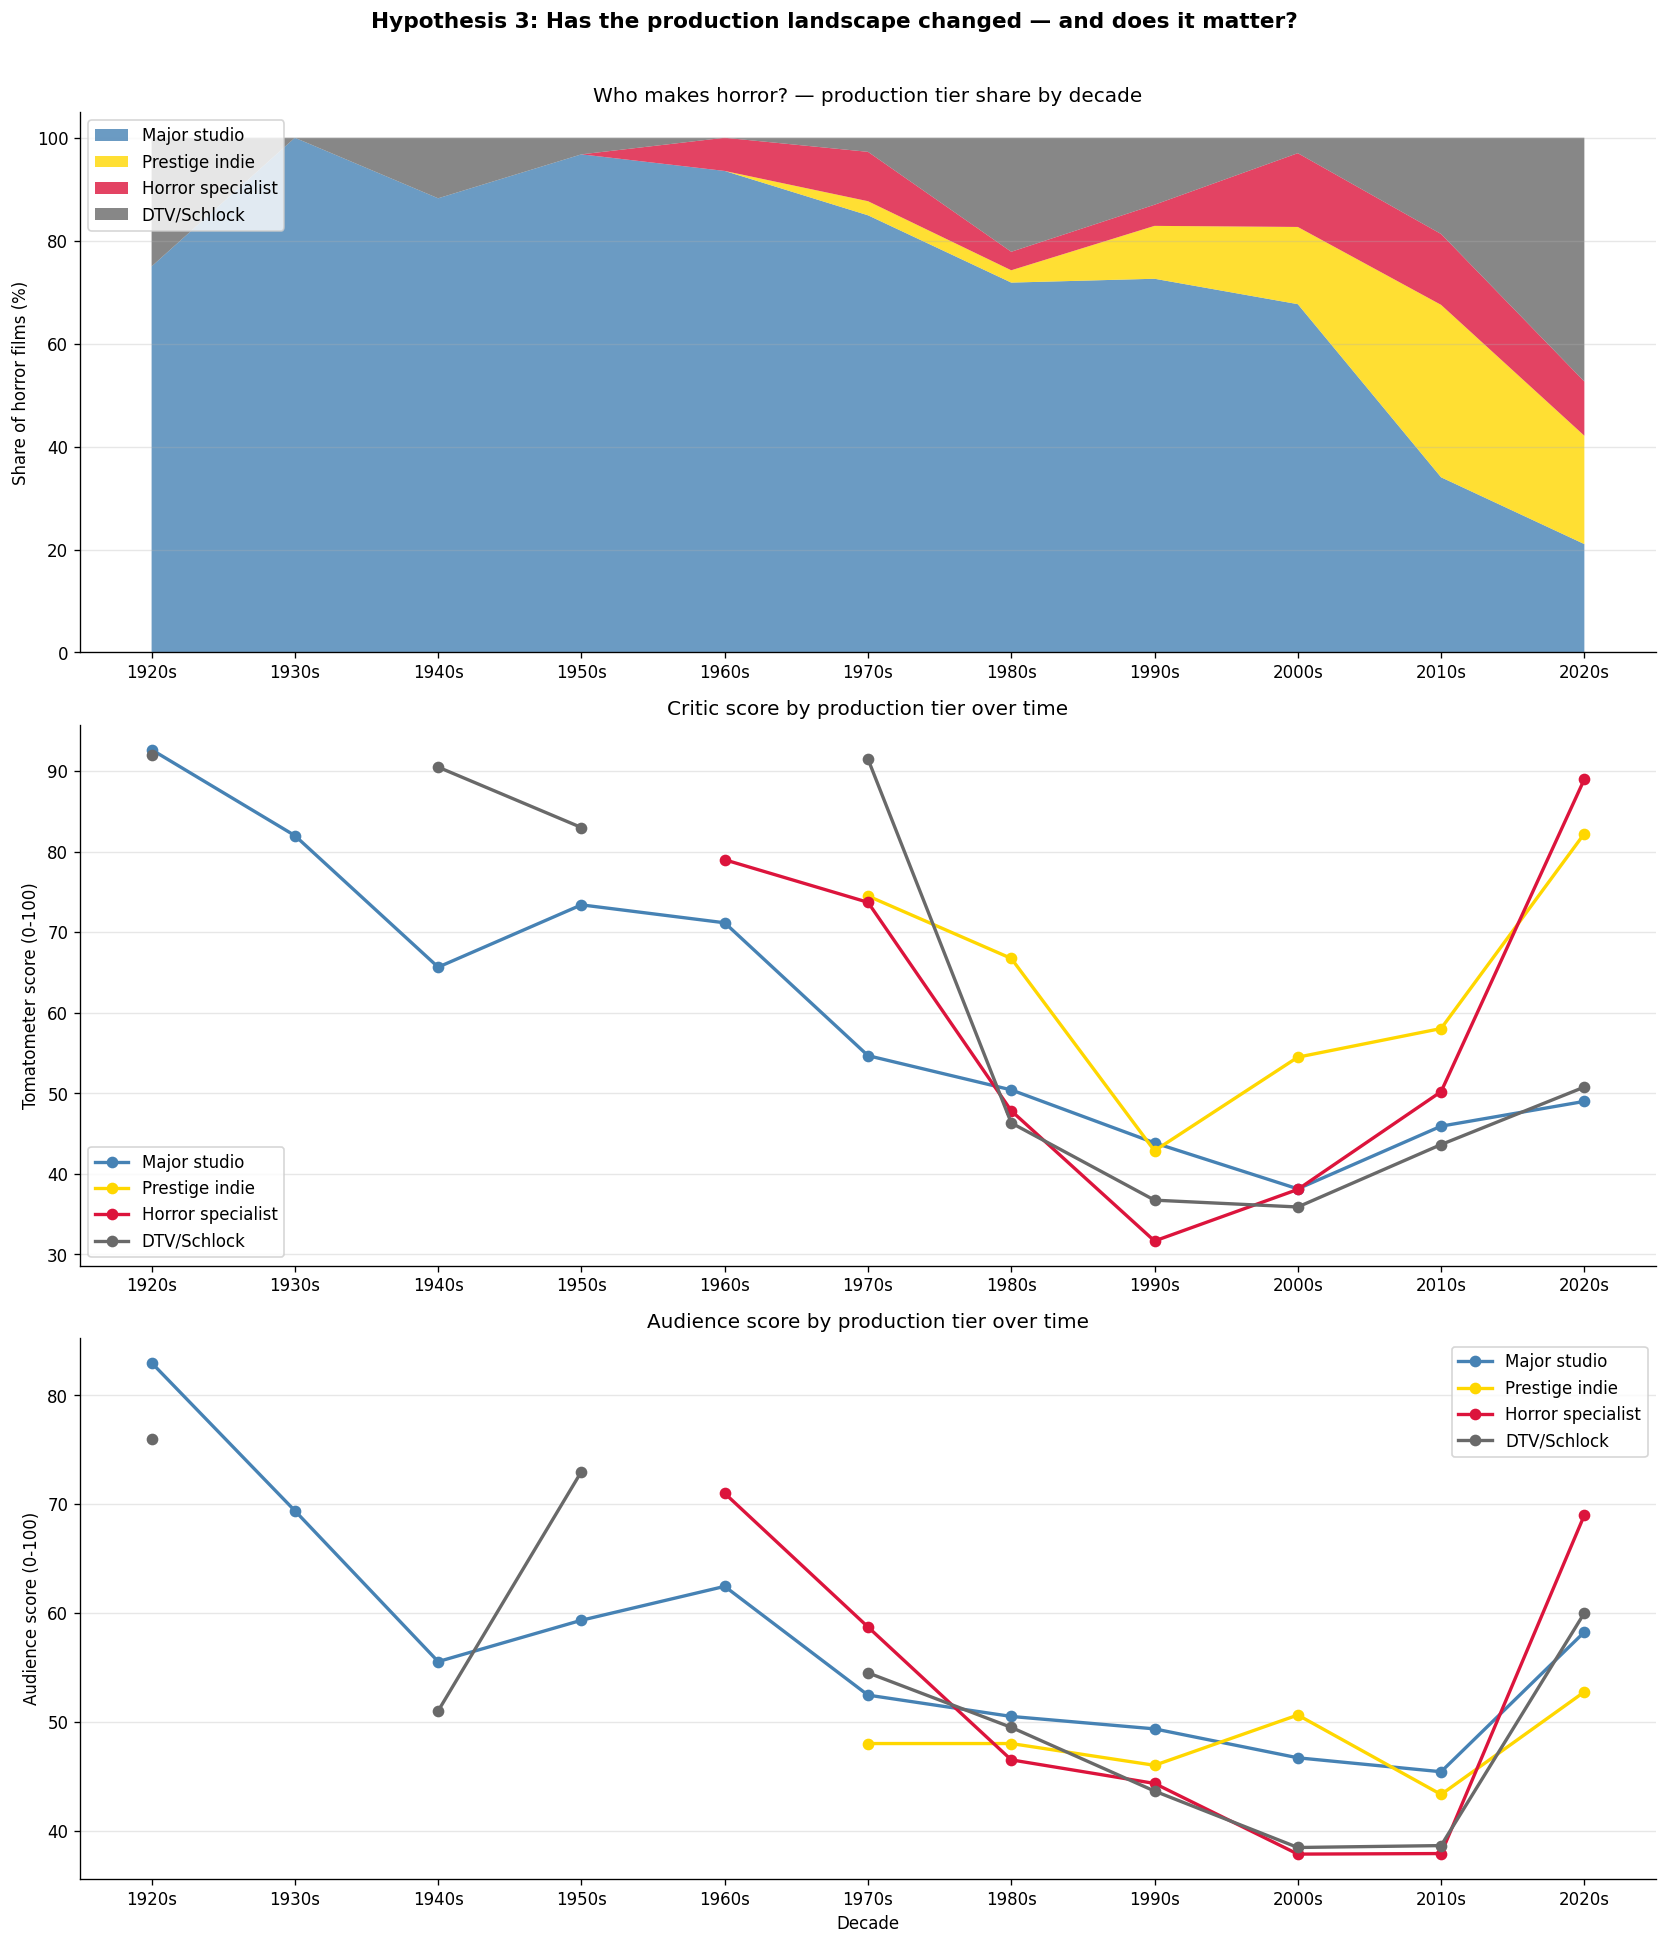

In [ ]:
# production company tier mapping
def map_company_tier(company):
    if pd.isna(company):
        return 'Unknown'
    c = company.lower()
    if any(x in c for x in ['netflix', 'amazon', 'hulu', 'apple', 'peacock', 'hbo max']):
        return 'Streaming'
    if any(x in c for x in ['a24', 'ifc', 'magnolia', 'neon', 'focus features',
                              'fox searchlight', 'miramax', 'radius', 'magnet', 'tribeca', 'momentum', 'blue underground']):
        return 'Prestige indie'
    if any(x in c for x in ['universal', 'warner', 'paramount', 'disney',
                              '20th century', 'columbia', 'sony', 'mgm',
                              'lionsgate', 'lions gate', 'new line', 'fox',
                              'tristar', 'united artists', 'summit', 'weinstein', 'hbo', 'avco']):
        return 'Major studio'
    if any(x in c for x in ['blumhouse', 'ghost house', 'platinum dunes',
                              'dimension', 'screen gems', 'after dark', 'anchor bay', 'dark sky', 'epic pictures']):
        return 'Horror specialist'
    if any(x in c for x in ['trimark', 'troma', 'vestron', 'live home',
                              'new world', 'media home', 'gravitas',
                              'vertical entertainment', 'uncork', 'saban',
                              'freestyle', 'rlje', 'xlrator', 'rlj', 'image entertainment']):
        return 'DTV/Schlock'
    return 'Other'

rt_horror['company_tier'] = rt_horror['production_company'].apply(map_company_tier)

tiers_to_use = ['Major studio', 'Prestige indie', 'Horror specialist', 'DTV/Schlock']
rt_horror_tiered = rt_horror[rt_horror['company_tier'].isin(tiers_to_use)]

# tier share by decade
tier_by_decade = rt_horror_tiered.groupby(['decade', 'company_tier']).size().unstack(fill_value=0)
tier_share = tier_by_decade.div(tier_by_decade.sum(axis=1), axis=0) * 100

# ratings by tier and decade
critic_by_tier = rt_horror_tiered.groupby(['decade', 'company_tier'])['tomatometer_rating'].mean().unstack()
audience_by_tier = rt_horror_tiered.groupby(['decade', 'company_tier'])['audience_rating'].mean().unstack()

tier_colors = {
    'Major studio': 'steelblue',
    'Prestige indie': 'gold',
    'Horror specialist': 'crimson',
    'DTV/Schlock': 'dimgray'
}

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# chart 1 - stacked area
axes[0].stackplot(tier_share.index,
                  [tier_share[t] for t in tiers_to_use],
                  labels=tiers_to_use,
                  colors=[tier_colors[t] for t in tiers_to_use],
                  alpha=0.8)
axes[0].set_title('Who makes horror? — production tier share by decade')
axes[0].set_ylabel('Share of horror films (%)')
axes[0].legend(loc='upper left')
axes[0].grid(axis='y', alpha=0.3)

# chart 2 - critic score by tier
for tier in tiers_to_use:
    axes[1].plot(critic_by_tier.index, critic_by_tier[tier], marker='o',
                linewidth=2, label=tier, color=tier_colors[tier])
axes[1].set_title('Critic score by production tier over time')
axes[1].set_ylabel('Tomatometer score (0-100)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# chart 3 - audience score by tier
for tier in tiers_to_use:
    axes[2].plot(audience_by_tier.index, audience_by_tier[tier], marker='o',
                linewidth=2, label=tier, color=tier_colors[tier])
axes[2].set_title('Audience score by production tier over time')
axes[2].set_ylabel('Audience score (0-100)')
axes[2].set_xlabel('Decade')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Hypothesis 3: Has the production landscape changed — and does it matter?', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Finding: Production landscape
The composition of who makes horror has fundamentally shifted over five decades:

- **1970s-1980s**: Major studios dominated at 85-72% of horror output
- **2000s**: Horror specialists (Blumhouse, Dimension) grew to 14% as studios began franchising the genre
- **2010s**: The landscape split — Major studio share collapsed to 34%, Prestige indie exploded to 33%, DTV/Schlock returned to 19%
- **2020s**: DTV/Schlock jumped to 47%, reflecting the flood of low-budget streaming content

**This structural shift explains both sides of the critic/audience divergence:**
- Prestige indie (A24, IFC, Magnolia) consistently rates highest with critics and grew from 2% to 33% of output — driving critical recovery
- DTV/Schlock rates worst with audiences in every decade and exploded in the 2020s — dragging audience scores down
- Major studio horror, which occupied the stable middle ground, has been steadily displaced

The 2010s audience score low point coincides exactly with the decade where the production landscape was most fragmented — horror split into prestige and schlock with little in between, and audiences rejected the lower end at scale.

## 4. Summary & conclusions

**Research question 1: Has horror's popularity changed over time?**
Yes. Horror peaked in the 1980s slasher era (19% of notable films), collapsed in the 1990s (8.9%), and has been recovering since. This pattern is unique to horror — peer genres do not show the same trough.

**Research question 2: Have horror ratings changed — and do critics and audiences agree?**
Both scores declined from the 1970s through the 2010s, but they tell different stories. Critics and audiences diverged sharply in the 2010s — critics recovered as prestige horror emerged, while audience scores hit their lowest point. The 2020s show recovery on both measures.

**Research question 3: What explains the changes?**
Three factors were tested:

| Factor | Critics | Audiences |
|---|---|---|
| Volume (films per year) | Not significant | Significant — more films, lower scores |
| Content rating | Strongly significant — PG-13 penalised, NR rewarded | Not significant — audiences don't care |
| Production tier | Prestige indie drives recovery | DTV/Schlock growth drives decline |

**The core finding:** Horror's rating trajectory is not a single story — it is the result of the genre splitting into two opposite extremes. A small number of high-quality prestige films elevated critical standing, while a flood of low-budget DTV and streaming content depressed audience scores. Volume amplified the effect on audience side. The genre is not getting better or worse — it is getting more polarised.

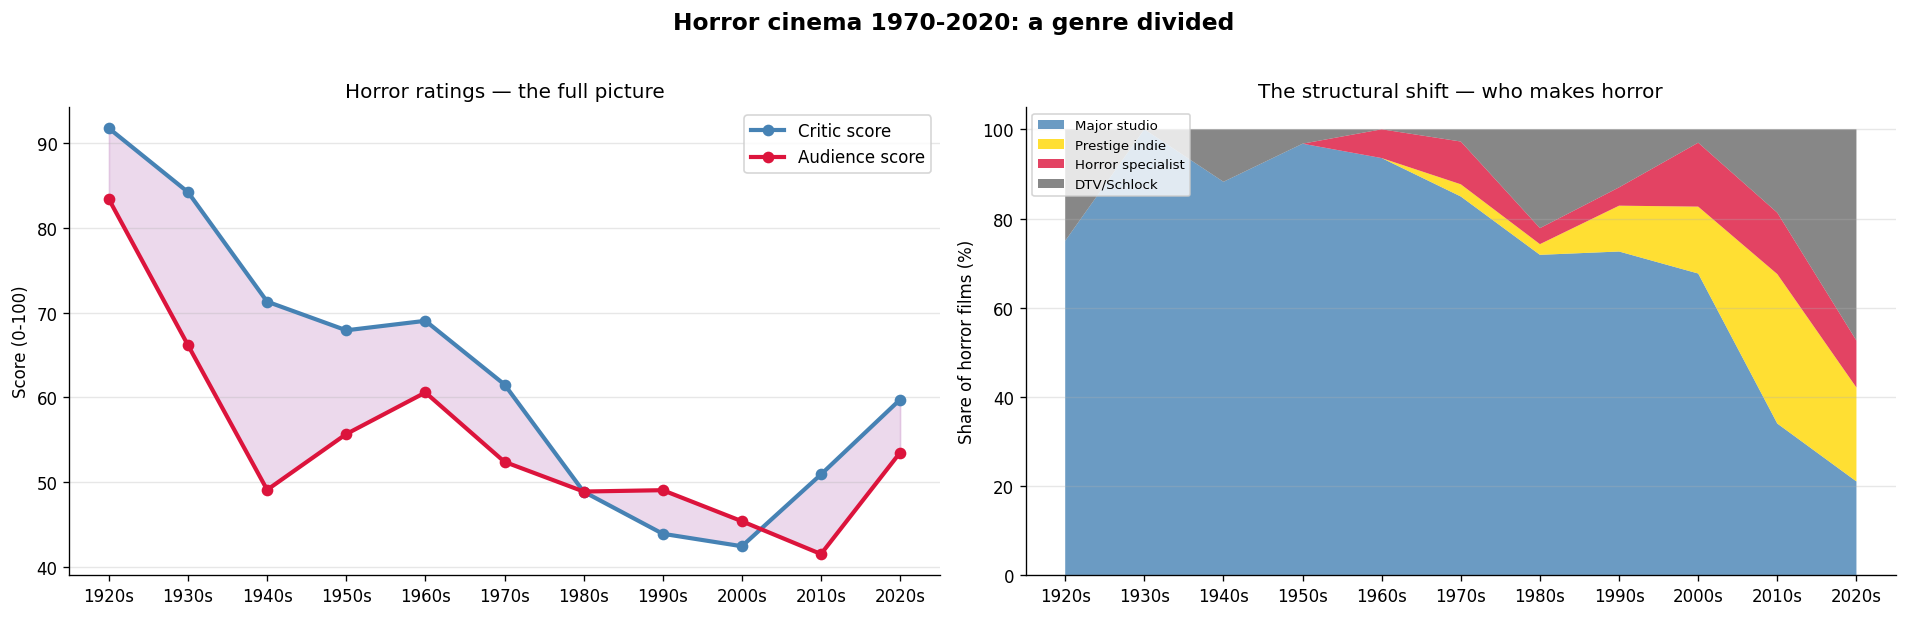

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left - the full ratings story in one chart
axes[0].plot(rating_by_decade.index, rating_by_decade['critic_score'],
             color='steelblue', linewidth=2.5, marker='o', label='Critic score')
axes[0].plot(rating_by_decade.index, rating_by_decade['audience_score'],
             color='crimson', linewidth=2.5, marker='o', label='Audience score')
axes[0].fill_between(range(len(rating_by_decade)),
                     rating_by_decade['critic_score'],
                     rating_by_decade['audience_score'],
                     alpha=0.15, color='purple')
axes[0].set_xticks(range(len(rating_by_decade)))
axes[0].set_xticklabels(rating_by_decade.index)
axes[0].set_title('Horror ratings — the full picture')
axes[0].set_ylabel('Score (0-100)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# right - production tier share as a summary of the structural shift
axes[1].stackplot(tier_share.index,
                  [tier_share[t] for t in tiers_to_use],
                  labels=tiers_to_use,
                  colors=[tier_colors[t] for t in tiers_to_use],
                  alpha=0.8)
axes[1].set_title('The structural shift — who makes horror')
axes[1].set_ylabel('Share of horror films (%)')
axes[1].legend(loc='upper left', fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Horror cinema 1970-2020: a genre divided', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()